# Neural Networks

This section provides implementation for concepts related to neural network models. Make sure that you have downloaded and installed the latest release of the `scimlstudio` package before running the code in this section.

A neural network is a machine learning model inspired by the human brain, capable of approximating nonlinear functions through interconnected layers of computational units known as neurons. According to the universal approximation theorem, NN model with a sufficient number of layers and neurons can represent almost any function. There are many different kinds of neural networks but in this section we will be focusing on fully-connected neural networks (shown below), where each neuron in a given layer is connected to every neuron in the preceding layer.

```{image} images/net.png
:width: 350px
:align: center
```

Specifically, each neuron computes a weighted combination of its inputs, followed by the application of a nonlinear activation function. Mathematically, hidden layers of the network can be represented by a recursive relation given as

$$
\begin{equation*}
    \mathbf{z}_k = g ( \mathbf{W}_k \cdot \mathbf{z}_{k-1}  + \mathbf{b}_k ) \text{, } \forall \text{  } k \in \{1, \ldots, H \},
\end{equation*}
$$

where $\mathbf{z}_k$ is the output of $k^{th}$ layer, $\mathbf{z}_0$ represents the input layer (i.e. design variable $\mathbf{x} \in \mathbb{R}^n$) and $H$ is the total number of hidden layers. The $\mathbf{W}_k$ and $\mathbf{b}_k$ are weight matrix and bias vector of $k^{th}$ layer, respectively. The $g(\cdot)$ is a nonlinear activation function which operates element-wise on given input vector and significantly effects the performance of network. Several activation functions have been introduced such as sigmoid, hyperbolic tan (tanh) and rectified linear unit (ReLU). All these activation functions are shown in below figure.

```{image} images/act_funcs.png
:width: 350px
:align: center
```

Mathematically, some of these activation functions are written as:

$$
\begin{gathered}
    \text{Sigmoid: } g(z) = \frac{1}{1 + \exp(-z)} \\ ~ \\
    \text{Tanh: } g(z) = \frac{\exp(z) - \exp(-z)} {\exp(z) + \exp(-z)} \\ ~ \\
    \text{ReLU: } g(z) = \max(0, x) \\ ~ \\
    \text{SiLU: } g(z) = \frac{z}{1 + \exp(-z)}
\end{gathered}
$$

For regression problems, output of the network is a linear combination of the last layer, computed as

$$
\begin{equation}
    \hat{\mathbf{y}} = \mathbf{W}_{H+1} \cdot \mathbf{z}_{H}  + \mathbf{b}_{L+1},
\end{equation}
$$

where $\hat{\mathbf{y}} \in \mathbb{R}^m$ is the output of the network. The weights and biases are together known as parameters of the network, $\pmb{\phi} = \{\mathbf{W}_k, \mathbf{b}_k\}_{k=1}^{H+1}$, and are computed by minimizing a loss function $\mathcal{L}(\pmb{\phi})$. Depending on the task, there are many different types of loss function. For regression problems, we will use mean squared error which captures the difference between true and predicted output values for the given dataset $\mathcal{D} = \{(\mathbf{x}^{(1)},\mathbf{y}^{(1)}), \dots, (\mathbf{x}^{(N)},\mathbf{y}^{(N)}) \}$. Mathematically, it can be written as

$$
\begin{equation}
      \pmb{\phi}^* = \min_{\pmb{\phi}} \mathcal{L}(\pmb{\phi}) = \min_{\pmb{\phi}} \frac{1}{N} \sum_{i=1}^{N} \Big \lVert \mathbf{y}^{(i)} - \hat{\mathbf{y}}(\mathbf{x}^{(i)},\pmb{\phi}) \Big \rVert^2_2.
\end{equation}
$$

Solving above problem is challenging due to the large number of parameters. Typically, a gradient descent optimization is performed where the gradient of loss function $\mathcal{L}$ with respect to $\pmb{\phi}$ is computed using backpropagation algorithm. In this work, Adaptive Moments (ADAM) optimization algorithm is used to obtain $\pmb{\phi}^*$. Refer to lecture notes for more details about neural networks and how they are trained.

> __NOTE__: Neural network model can be used for learning various kinds of data such as images, time series, mesh/graphs, etc. It can handle noisy data as well. It also works with different variable types, including continuous and discrete/categorical. You will have to choose an architecture that supports the data you want to use.

> __NOTE__: Unlike gaussian process regression, neural network is not an interpolating model. Sometimes, it may appear that neural network prediction is interpolating through the training data but it is often not the case.

Below code block imports required packages:

In [1]:
import torch
from scimlstudio.models import FeedForwardNeuralNetwork
from scimlstudio.utils import Standardize, evaluate_scalar
import matplotlib.pyplot as plt

# defining the device and data types
args = {
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    "dtype": torch.float32
}

/home/pavan/miniconda3/envs/sm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


> __NOTE__: Typically, it is sufficient to use `float32` data type while working with neural networks. PyTorch package works well for this data type and increasing it to `float64` might not provide additional benefits, while slowing down training/prediction process and consuming double the memory.

## Toy problem

We will demonstrate neural networks using the following mixed-integer function:

$$
y(x,z) = \begin{cases}
    \cos(3.6\pi(x-2)) + x - 1, & z = 0 \\
    \\
    2\cos(1.1\pi e^x) - \dfrac{x}{2} + 2, & z = 1\\
    \\
    x\Bigg[\cos(3.4\pi(x-1)) - \dfrac{x-1}{2}\Bigg], & z = 2
\end{cases},
$$

where $x \in [0,1]$ and $z \in {0, 1, 2}$. Let's define a function that can compute $y$ for a given $x$ and $z$.

In [1]:
def test_function(x):
    """
        `x` contains both continuous and discrete variable
    """

    x = torch.atleast_2d(x)

    y = torch.zeros(x.shape[0],1).to(x)

    for z in [0,1,2]:

        mask = x[:,1] == z
        x_tmp = x[mask,0]

        if z == 0:
            y[mask,0] = torch.cos(3.6*torch.pi*(x_tmp-2)) + x_tmp - 1 
        elif z == 1:
            y[mask,0] = 2*torch.cos(1.1*torch.pi*torch.exp(x_tmp)) - x_tmp/2 + 2
        elif z == 2:
            y[mask,0] = x_tmp*( torch.cos(3.4*torch.pi*(x_tmp-1)) - (x_tmp-1)/2 ) 

    return y

Now, let's create training and testing data. We are using only 4 points along each value of $z$. This results in 12 training points in total. Similarly, testing dataset contains 100 points along each $z$. Since this a toy function, testing data is much larger than training data. Typically, training data is larger than testing data.

In [3]:
# training
x_cont = torch.linspace(0, 1, 4, **args)
x = []
for z in [0,1,2]:
    x.append(torch.hstack((x_cont.reshape(-1,1), z*torch.ones(x_cont.shape[0],1,**args)) ))
xtrain = torch.vstack(x)
ytrain = test_function(xtrain)

# testing/plotting
x_cont = torch.linspace(0, 1, 100, **args)
x = []
for z in [0,1,2]:
    x.append(torch.hstack((x_cont.reshape(-1,1), z*torch.ones(x_cont.shape[0],1,**args)) ))
xplot = torch.vstack(x)
yplot = test_function(xplot)

Next code block plots the training and testing data. Note that the solid lines are created using the testing data and scatter points denote training data.

Text(0.5, 1.0, 'True function with training data')

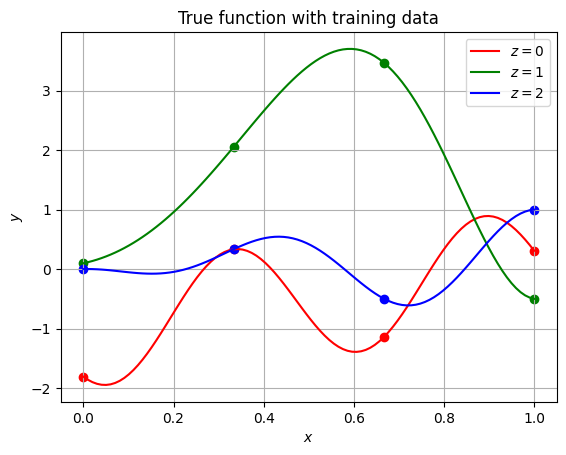

In [4]:
fig, ax = plt.subplots()

c = ["r", "g", "b"]

ax.grid()

for z in [0,1,2]:
    mask = xplot[:,1] == z
    x_tmp = xplot[mask,0]

    ax.plot(x_tmp.numpy(force=True), yplot[mask,0].numpy(force=True), f"{c[z]}-", label=f"$z={z}$")

    mask = xtrain[:,1] == z
    x_tmp = xtrain[mask,0]

    ax.scatter(x_tmp.numpy(force=True), ytrain[mask,0].numpy(force=True), c=f"{c[z]}")

ax.legend()
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("True function with training data")

## Define NN model

We will use `FeedForwardNeuralNetwork` class from `scimlstudio` package for creating a fully-connected neural network. This class can be used to create any sort of feed-forward model, such as multi-layer perceptron and convolutional neural network, for a supervised learning task.

The `FeedForwardNeuralNetwork` class takes following arguments during initialization:

- `x_train`: a 2D torch tensor representing input training data
- `y_train`: a 2D torch tensor representing the output data
- `network`: an instance of `Sequential` class defining the neural network model architecture
- `input_transform`: an instance of `Normalize` or `Standardize` class used for input scaling, default = None
- `output_transform`: an instance of `Normalize` or `Standardize` class used for output scaling, default = None

First, let's define network architecture using the [`Sequential`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html) class. To initialize this class, you need to pass instances of various modules in the order you want to process the data. Here, module refers to various classes provided by torch package for performing computation on the data. Let's define a simple network to illustrate how this class works. The network will consist of two hidden layers with SiLU activation function, where each layer consists of 32 neurons. Below code block defines this network:

In [5]:
network = torch.nn.Sequential(
    torch.nn.Linear(xtrain.shape[1], 32),
    torch.nn.SiLU(),
    torch.nn.Linear(32, 32),
    torch.nn.SiLU(),
    torch.nn.Linear(32, 1),
).to(**args)

Notice how the class is initialized. It uses two different modules - `Linear` and `SiLU`. The [`Linear`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html) module primarily takes two arguments - input size and output size. Essentially, `Linear` module takes input $\mathbf{x}$ and performs a linear transformation:

$$
    \mathbf{z} = W\mathbf{x} + \mathbf{b},
$$

where $W$ is the weight matrix (size is based on output and input size) and $\mathbf{b}$ is the bias. The `SiLU` module represents your activation function. It takes an input and applies a nonlinear function elementwise. You can check [here](https://docs.pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity) the list of various activation functions available in torch. You can also write your own activation function.

### Initialization

It has been shown that the performance of the network can be improved if the weights within in a particular layer are initialized based on the number of inputs and outputs and the type of activation function. Read more about weight initialization from following papers:

[1] [X. Glort, and Y. Bengio. Understanding the difficulty of training deep feedforward neural networks. International Conference on Artificial Intelligence and Statistics, 2010](https://proceedings.mlr.press/v9/glorot10a)

[2] [K. He, X. Zhang, S. Ren, J. Sun. Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification](https://proceedings.mlr.press/v9/glorot10a)

You can check [here](https://docs.pytorch.org/docs/stable/nn.init.html) various initilization methods available in torch. Below code block initializes the network weight using glorot (or xavier) normal initialization, and the network biases are initialized to zero. The xavier normal method initializes weights in a layer by randomly sampling from $\mathcal{N}(0,\sigma^2)$, where standard deviation is computed as

$$
    \sigma = \text{gain} \sqrt{ \dfrac{2}{\text{input size} + \text{output size}} }.
$$

Note that here we are only setting the starting point for the network parameters, which will be later updated during network training.

In [ ]:
def init_weights(m):
    """
        Function for initializing the weights using glorot (or xavier) normal initialization
    """

    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_normal_(m.weight) # change this for other init methods
        m.bias.data.fill_(0.0)

# initial weights
network.apply(init_weights)

Now, we can define the `FeedForwardNeuralNetwork` class with `Sequential` class object. In below block, input and output transform are also defined. 

> __NOTE__: It is very important to scale (either standardize or normalize) the data while working with neural networks. This makes it easier for the network to learn from the data. For regression problems, input and output data is usually standardized to zero mean and unit variance.

In [6]:
input_transform = Standardize(xtrain)
output_transform = Standardize(ytrain)

# initialize the model class
model = FeedForwardNeuralNetwork(xtrain, ytrain, network, input_transform, output_transform)

## Train NN model

Now, we can train the network using the `fit` method from the `FeedForwardNeuralNetwork` class object created in previous code block. This method takes following arguments:

* `optimizer`: an object from torch.optim module to optimize the network parameters
* `loss_func`: an object from torch.nn.Module.loss module to compute the loss during training
* `batch_size`: batch size to use during training, default = 1
* `epochs`: number of epochs to train the network, default = 100

Below code block defines these arguments and trains the model. In this demonstration, we are using [`Adam`](https://arxiv.org/abs/1412.6980) method to optimize the network parameters. You can check [here](https://docs.pytorch.org/docs/stable/optim.html#algorithms) the list of optimizers available in torch. While initializing the `Adam` class, we need to provide the varaibles to be optimized i.e. the model parameters. You can access the network parameters using the `parameters` variable from the `FeedForwardNeuralNetwork` class object. You can also get these parameters using `parameters()` method from the `Sequential` class object. The learning rate for optimization is also set to 0.01. Refer to the [documentation](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html#torch.optim.Adam) for a detailed list of arguments accepted by `Adam` class. When it comes to network training, it is also important that you understand the difference between mini-batching and epochs. Refer to lecture notes for more details.

Feel free to change arguments defined below and see how it affects the network training and prediction

In [7]:
optimizer = torch.optim.Adam(model.parameters, lr=0.01) # adam optimizer

loss_func = torch.nn.MSELoss() # mean squared error loss function

# since the training data is small, we are using entire data
batch_size = xtrain.shape[0] 

epochs = 100 # number of epochs

model.fit(optimizer, loss_func, batch_size,epochs) # call the fit method

For real-world problems, training a network is not a trivial problem. You will often run into [underfitting/overfitting](https://en.wikipedia.org/wiki/Overfitting) issues. There are many hyperparameters that govern the network performance and finding good values for them is often difficult. You may have to use various tools, such as [learning curves](https://en.wikipedia.org/wiki/Learning_curve_(machine_learning)) and hyperparameter [tuning/optimization](https://www.geeksforgeeks.org/machine-learning/hyperparameter-tuning/), for setting these hyperparameters.

## Predict

Once the network is trained, we can do predictions using it. You can use `predict` method from the `FeedForwardNeuralNetwork` class object for doing predictions. Below code evaluates network on the testing data and plots it:

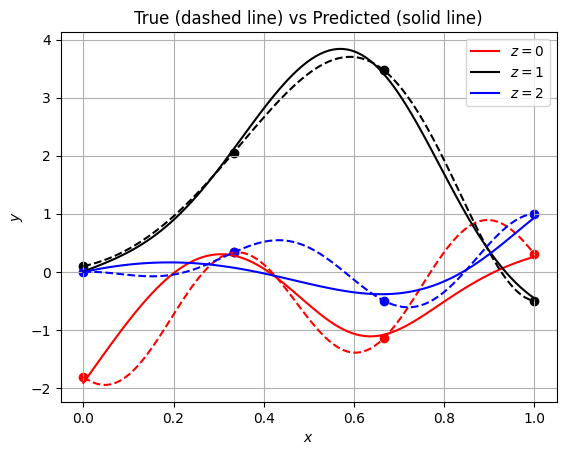

In [8]:
yplot_pred = model.predict(xplot) # predict

# plot
fig, ax = plt.subplots()

c = ["r", "k", "b"] # colors

# each level plot
for z in [0,1,2]:

    mask = xplot[:,1] == z
    x_tmp = xplot[mask,0]

    # true
    ax.plot(x_tmp.numpy(force=True), yplot[mask,0].numpy(force=True), f"{c[z]}--")

    # prediction
    ax.plot(x_tmp.numpy(force=True), yplot_pred[mask,0].numpy(force=True), f"{c[z]}-", label=f"$z={z}$")

    # training points
    mask = xtrain[:,1] == z
    x_tmp = xtrain[mask,0]
    ax.scatter(x_tmp.numpy(force=True), ytrain[mask,0].numpy(force=True), c=f"{c[z]}")

ax.legend()
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("True (dashed line) vs Predicted (solid line)")
ax.grid()

## Parity plots

Now, let's increase the number of training points and see how the network prediction evolves, along with testing NRMSE. For each training set, we plot the network prediction and corresponding parity plot.

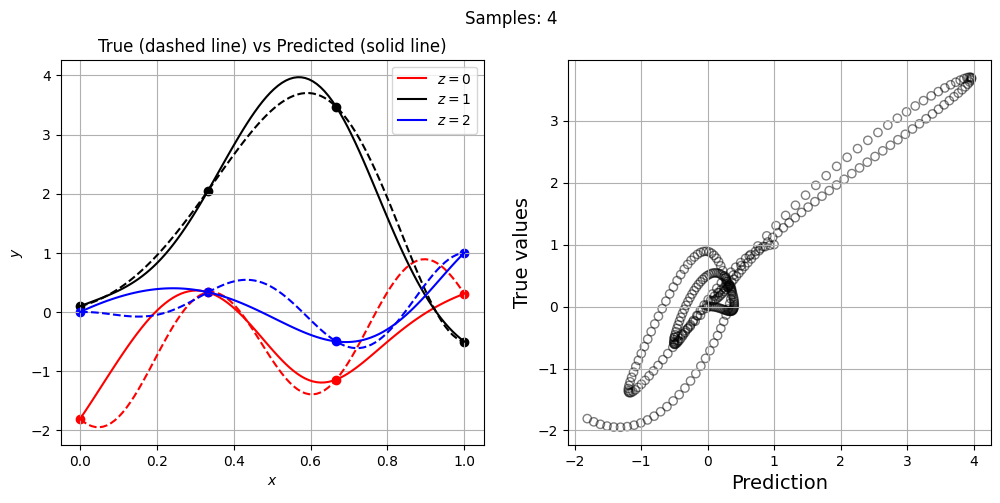

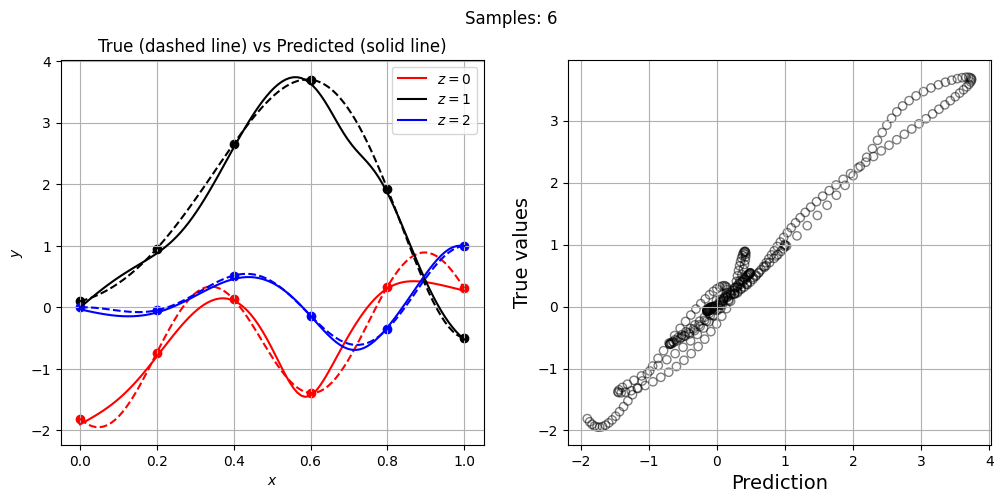

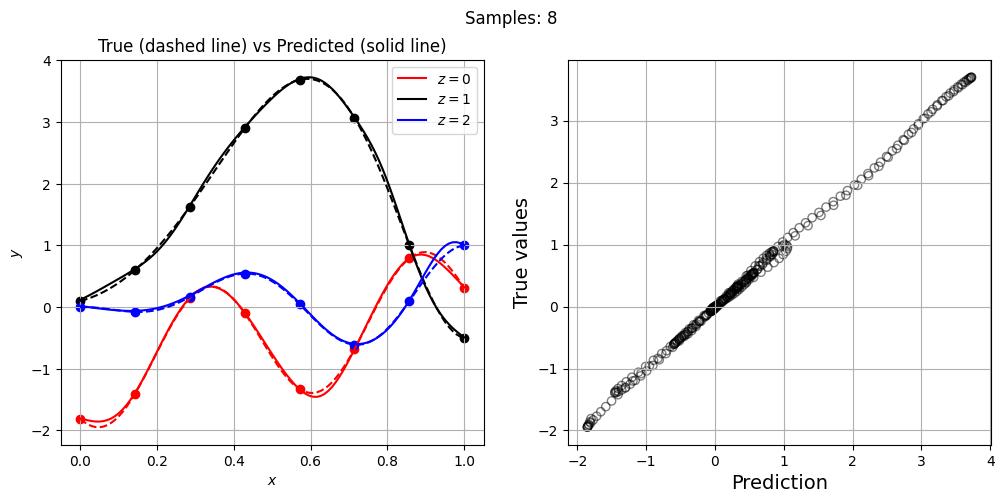

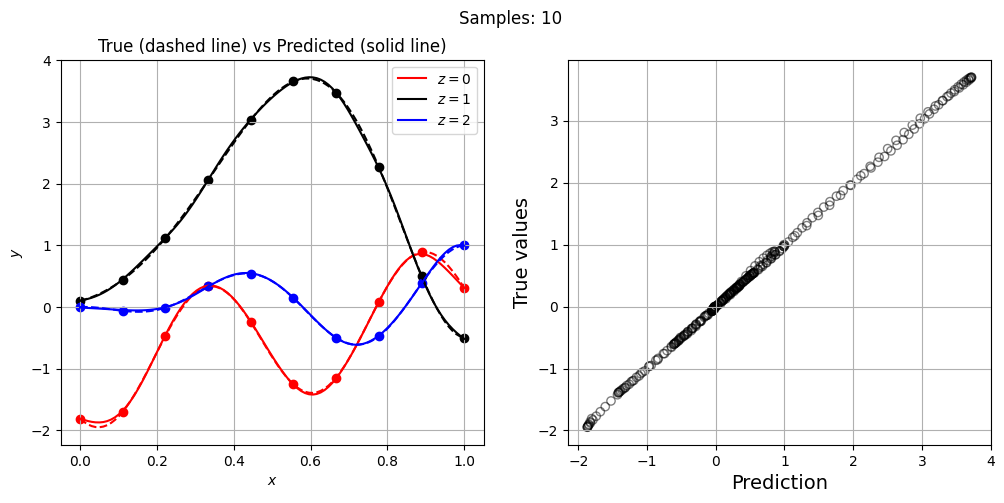

In [9]:
# training variables
optimizer = torch.optim.Adam(model.parameters, lr=0.01) # adam optimizer
loss_func = torch.nn.MSELoss() # mean squared error loss function
batch_size = xtrain.shape[0] # we are using entire data
epochs = 500 # number of epochs

# loop variables
training_pts = [4, 6, 8, 10] # points along each level
nrmse = []

for pts in training_pts:

    # training data
    x_cont = torch.linspace(0, 1, pts, **args)
    x = []
    for z in [0,1,2]:
        x.append(torch.hstack((x_cont.reshape(-1,1), z*torch.ones(x_cont.shape[0],1,**args)) ))
    xtrain = torch.vstack(x)
    ytrain = test_function(xtrain)

    # data scaling
    input_transform = Standardize(xtrain)
    output_transform = Standardize(ytrain)

    # initialize the model class
    model = FeedForwardNeuralNetwork(xtrain, ytrain, network, input_transform, output_transform)

    # train the network
    model.fit(optimizer, loss_func, batch_size,epochs)

    # predict
    yplot_pred = model.predict(xplot)

    # compute error
    metric = evaluate_scalar(yplot.reshape(-1,), yplot_pred.reshape(-1,), metric="nrmse")

    # append metric
    nrmse.append(metric)

    # plot
    fig, ax = plt.subplots(1, 2, figsize=(12,5))

    # each level plot
    for z in [0,1,2]:

        mask = xplot[:,1] == z
        x_tmp = xplot[mask,0]

        # true
        ax[0].plot(x_tmp.numpy(force=True), yplot[mask,0].numpy(force=True), f"{c[z]}--")

        # prediction
        ax[0].plot(x_tmp.numpy(force=True), yplot_pred[mask,0].numpy(force=True), f"{c[z]}-", label=f"$z={z}$")

        # training points
        mask = xtrain[:,1] == z
        x_tmp = xtrain[mask,0]
        ax[0].scatter(x_tmp.numpy(force=True), ytrain[mask,0].numpy(force=True), c=f"{c[z]}")

    ax[0].legend()
    ax[0].set_xlabel("$x$")
    ax[0].set_ylabel("$y$")
    ax[0].set_title("True (dashed line) vs Predicted (solid line)")
    ax[0].grid()

    # Parity plots
    ax[1].scatter(yplot_pred.numpy(force=True), yplot.numpy(force=True), facecolors="none", edgecolors='k', alpha=0.5)
    ax[1].set_xlabel("Prediction", fontsize=14)
    ax[1].set_ylabel("True values", fontsize=14)
    ax[1].grid()

    fig.suptitle(f"Samples: {pts}")

Let's plot NRMSE evolution as sample size is increased.

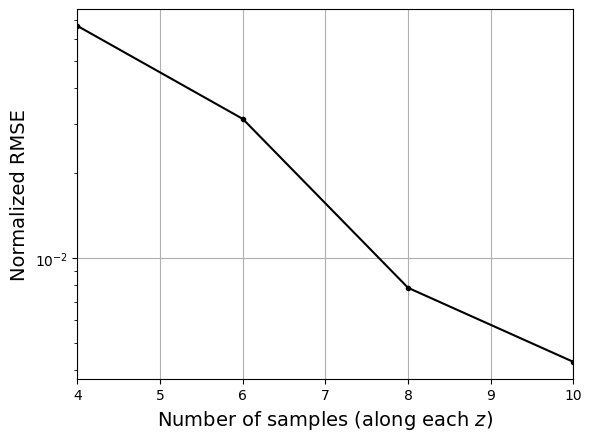

In [10]:
# Plotting NRMSE
fig, ax = plt.subplots()
ax.plot(training_pts, nrmse, c="k", marker=".")
ax.grid()
ax.set_yscale("log")
ax.set_xlim((training_pts[0], training_pts[-1]))
ax.set_xlabel("Number of samples (along each $z$)", fontsize=14)
_ = ax.set_ylabel("Normalized RMSE", fontsize=14)

> __NOTE__: Neural network parameters are initialized randomly. Moreover, the training process involves randomness. Due to this, everytime you initialize and/or train the network, you will get different results.